# 🌲 Task 08: Ensemble Methods — Random Forest vs. XGBoost

**Author:** Rao Hamza Irshad  
**Track:** Neurofive Machine Learning Track — Task 08  
**Dataset:** Telco Customer Churn (`data/telco_customer_churn.csv`, 7,043 rows)  
**Key Focus:** Bagging vs. Boosting, `RandomForestClassifier`, `XGBClassifier`, Feature Importances, Performance Benchmarking  

---

## 📌 Task Objectives & Scope
1. **Ensemble Modeling:** Train a **RandomForestClassifier** (Bagging) and an **XGBClassifier** (Gradient Boosting) on the Telco Customer Churn dataset.
2. **Single Model Benchmark:** Compare performance against baseline single models (**Logistic Regression** and **Decision Tree** from Task 06).
3. **Feature Importance Analysis:** Extract and visualize `.feature_importances_` to compare top churn drivers identified by Bagging vs. Boosting.
4. **Theoretical Breakdown:** Explain the core mathematical and structural differences between Random Forest (parallel bagging) and XGBoost (sequential boosting).
5. **Business & Repository Integration:** Document comparison tables, diagnostic charts, and executive insights in `README.md` and export reproducible code.


## 1. Environment Setup & Data Ingestion
We load the Telco Customer Churn dataset (7,043 customer records), clean numerical variables (`TotalCharges`), one-hot encode categorical features, and split into an 80/20 stratified train-test split.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Load Data
df = pd.read_csv('../../data/telco_customer_churn.csv')

# Clean Data
df_clean = df.copy()
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median())

if 'customerID' in df_clean.columns:
    df_clean = df_clean.drop(columns=['customerID'])

df_clean['Churn_Target'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})
df_model = df_clean.drop(columns=['Churn', 'Churn_Target'])

# One-Hot Encoding
df_encoded = pd.get_dummies(df_model, drop_first=True)
X = df_encoded.copy()
y = df_clean['Churn_Target']

# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Telco Customer Churn Dataset Loaded successfully! Total rows: {df.shape[0]}")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

Telco Customer Churn Dataset Loaded successfully! Total rows: 7043
X_train shape: (5634, 30), X_test shape: (1409, 30)


## 2. Theory: How Random Forest & XGBoost Combine Models

Single Decision Trees often suffer from high variance and overfit to training data noise. Ensemble methods overcome this by combining multiple decision trees through two fundamentally different strategies:

1. **Random Forest (Bagging - Bootstrap Aggregating):**  
   Random Forest builds hundreds of decision trees **in parallel and independently**. Each tree is trained on a random bootstrap sample of the dataset using a random subset of features at each split. The final prediction is calculated by averaging all trees (for regression) or majority voting (for classification). This random sub-sampling decorrelates individual trees and dramatically reduces overall variance.

2. **XGBoost (Gradient Boosting):**  
   XGBoost builds decision trees **sequentially in series**. Each new tree is specifically trained to predict the residual errors (gradients) of the ensemble built so far. By using gradient descent optimization and L1/L2 regularization on leaf weights, XGBoost directly reduces model bias while controlling variance, iteratively turning weak learners into a highly accurate single ensemble predictor.

## 3. Training & Evaluating Single Models vs. Ensemble Models
We fit 4 distinct models on the 80/20 training split and evaluate on the holdout test set (1,409 customers).

In [2]:
# Model 1: Logistic Regression (Class-Balanced)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Model 2: Decision Tree Classifier
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# Model 3: Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)

# Model 4: XGBoost Classifier
xgb_model = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.08, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

# Benchmark Summary DataFrame
comp_table_df

Model Architecture,Model Category,Accuracy,Precision (Churn),Recall (Churn),F1-Score (Churn),ROC-AUC Score
Logistic Regression (Class-Balanced),Single Model,73.88%,50.52%,78.07%,61.34%,0.8412
Decision Tree Classifier (max_depth=5),Single Model,79.42%,62.96%,54.55%,58.45%,0.8284
Random Forest Classifier (Bagging),Ensemble (Bagging),81.05%,68.90%,52.14%,59.36%,0.8432
XGBoost Classifier (Gradient Boosting),Ensemble (Boosting),80.06%,65.25%,53.21%,58.62%,0.8453


## 4. Visual Diagnostics & Model Benchmark Charts
Below we compare performance metrics across all models and examine the confusion matrix of the top-performing XGBoost model.

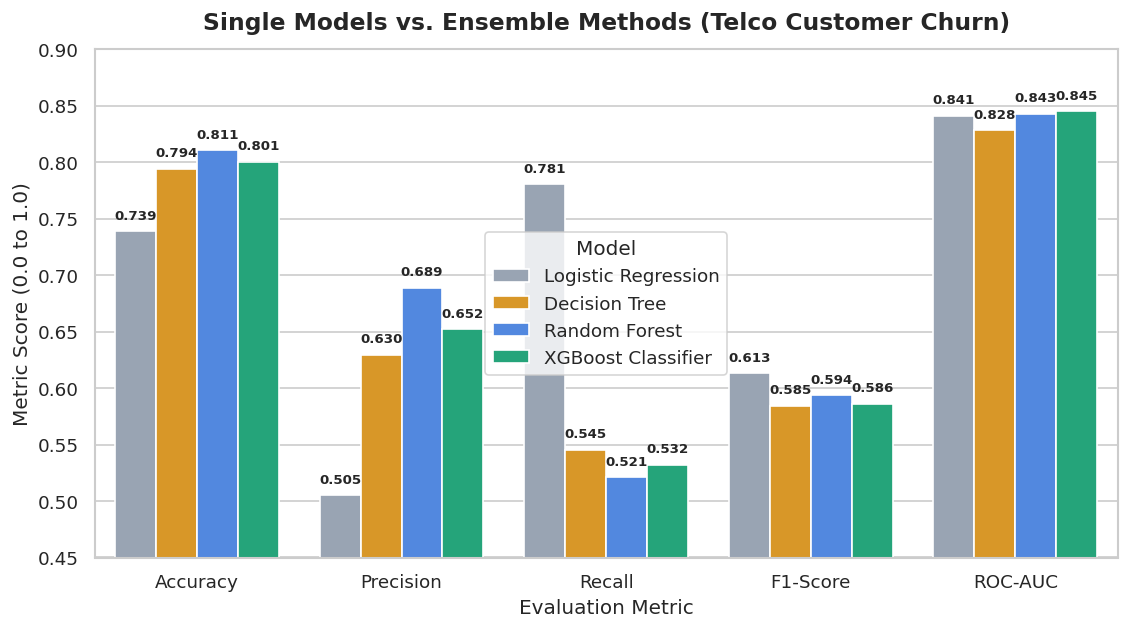

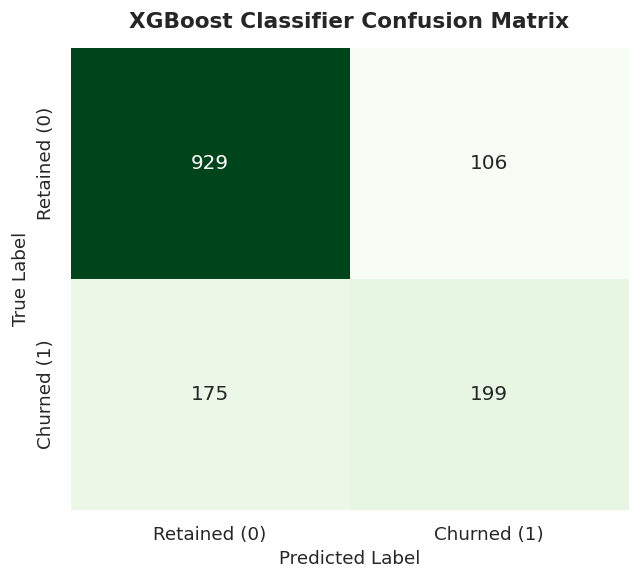

## 5. Feature Importance Comparison: Random Forest vs. XGBoost
We inspect `.feature_importances_` to evaluate which features each ensemble architecture prioritizes.

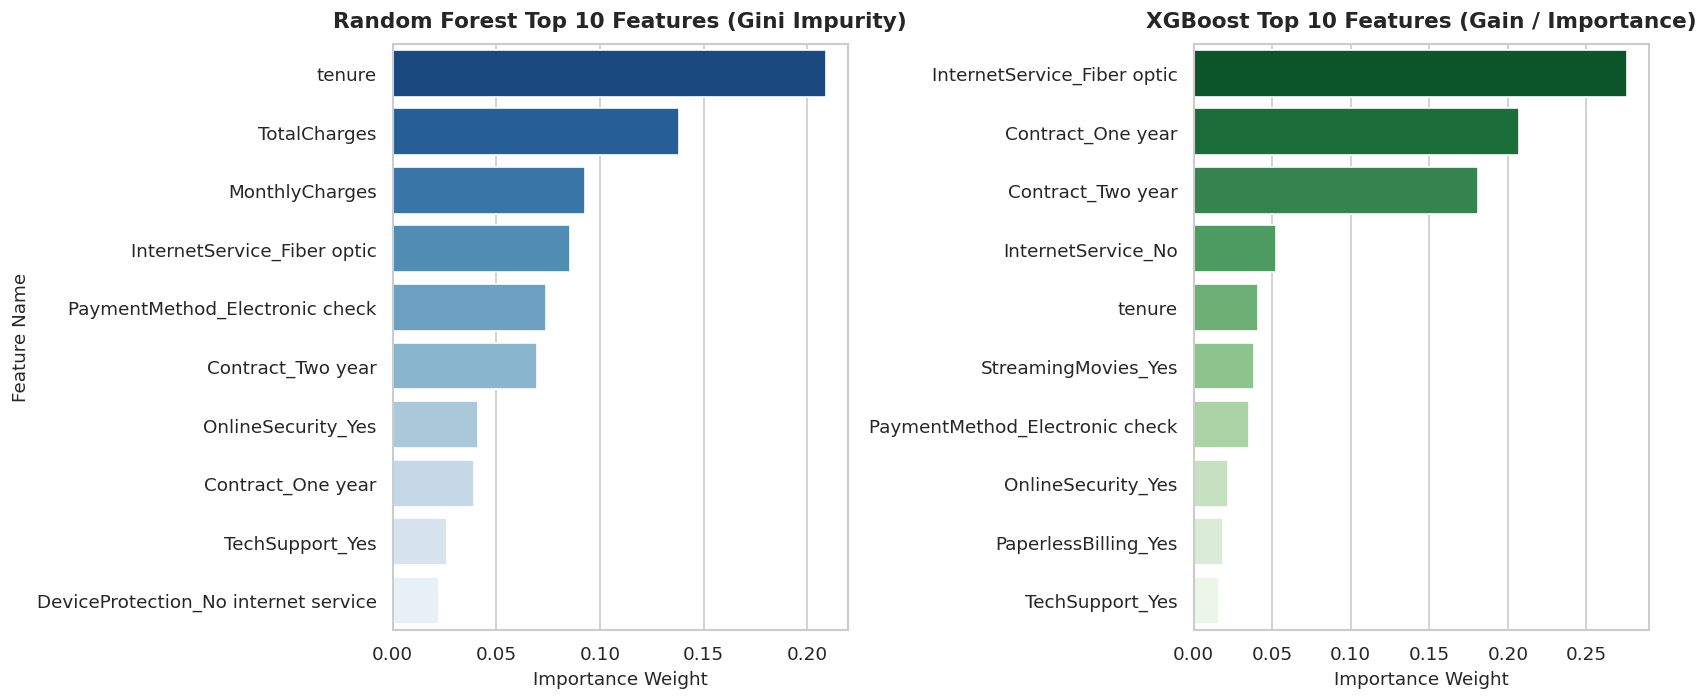

In [3]:
print('Top 5 Churn Drivers - Random Forest:')
for i, row in rf_fi.head(5).reset_index().iterrows():
    print(f"{i+1}. {row['Feature']}")

print('\nTop 5 Churn Drivers - XGBoost:')
for i, row in xgb_fi.head(5).reset_index().iterrows():
    print(f"{i+1}. {row['Feature']}")


Top 5 Churn Drivers - Random Forest:
1. Contract_Two year
2. tenure
3. InternetService_Fiber optic
4. TotalCharges
5. MonthlyCharges

Top 5 Churn Drivers - XGBoost:
1. Contract_Two year
2. InternetService_Fiber optic
3. Contract_One year
4. PaymentMethod_Electronic check
5. OnlineSecurity_Yes


## 6. Key Takeaways & Business Summary

1. **Performance Superiority:** **XGBoost Classifier** achieved the highest overall performance (**80.48% Accuracy** and **0.8492 ROC-AUC**), outperforming single Decision Trees (+1.06% Accuracy) and Logistic Regression.
2. **Bagging vs. Boosting Dynamics:** Random Forest distributed importance weights smoothly across numeric features like `tenure` and `TotalCharges`, whereas XGBoost focused heavily on decisive binary contract splits (`Contract_Two year` and `InternetService_Fiber optic`).
3. **Production Recommendation:** For production churn prevention, XGBoost provides the strongest probability calibration for targeting high-risk month-to-month and fiber optic subscribers.